# Step 7 & 8: Stunting Prediction Modeling and Explainable AI

This notebook trains machine learning models for early stunting risk prediction, evaluates model performance, performs threshold tuning, and applies SHAP and LIME for model interpretation.


## 1. Setup and Imports


In [1]:
import math
import textwrap
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, make_scorer
)

import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Publication-style visual theme
# The paper uses clean multi-panel plots for numerical distributions,
# categorical distributions, and a detailed correlation matrix. This notebook
# follows the same structure with cleaner spacing, labels, and export quality.
# -----------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.titleweight": "bold",
    "axes.titlepad": 8,
    "axes.edgecolor": "#D1D5DB",
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.7,
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data/processed/dataset_final.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = MODEL_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

RANDOM_STATE = 42
TARGET_COL = "is_stunted"

CLASS_LABELS = {
    0: "Not Stunted",
    1: "Stunted"
}

CLASS_ORDER = ["Not Stunted", "Stunted"]
CLASS_PALETTE = {
    "Not Stunted": "#4E79A7",  # soft blue
    "Stunted": "#E15759"       # soft red
}

PRIMARY_BLUE = "#4E79A7"
RISK_RED = "#E15759"
NEUTRAL_GRAY = "#6B7280"
GRID_GRAY = "#E5E7EB"

METRIC_PALETTE = {
    "Accuracy": "#4E79A7",
    "Precision": "#59A14F",
    "Recall": "#E15759",
    "F1-Score": "#F28E2B",
    "AUC": "#B07AA1",
    "ROC-AUC": "#B07AA1",
}

FEATURE_LABELS = {
    "is_stunted": "Stunting Status",
    "birth_weight": "Birth Weight",
    "birth_weight_kg": "Birth Weight (kg)",
    "premature_status": "Premature Status",
    "breastfeeding": "Breastfeeding",
    "exclusive_breastfeeding": "Exclusive Breastfeeding",
    "age": "Child Age",
    "child_age": "Child Age",
    "weight": "Child Weight",
    "weight_kg": "Child Weight (kg)",
    "height": "Child Height",
    "height_cm": "Child Height (cm)",
    "father_education": "Father's Education",
    "mother_education": "Mother's Education",
    "father_education_level": "Father's Education Level",
    "mother_education_level": "Mother's Education Level",
    "father_occupation": "Father's Occupation",
    "mother_occupation": "Mother's Occupation",
    "child_gender": "Child Gender",
    "water": "Protected Water Source",
    "toilet": "Toilet with Septic Tank",
    "smoking": "Household Smoking",
    "household_food": "Household Food Expenditure",
    "protein_intake": "Protein Intake Expenditure",
    "pce": "Per Capita Expenditure",
    "mother_age_at_birth": "Mother's Age at Birth",
    "teenage_mother": "Teenage Mother",
    "high_risk_maternal_age": "High-Risk Maternal Age",
    "has_delivery_insurance": "Delivery Insurance",
}


def pretty_name(name, width=24):
    '''Convert column names into compact, readable plot labels.'''
    label = FEATURE_LABELS.get(str(name), str(name).replace("_", " ").title())
    return "\n".join(textwrap.wrap(label, width=width, break_long_words=False))


def style_axis(ax, grid_axis="y"):
    '''Apply clean journal-like axis styling.'''
    ax.grid(True, axis=grid_axis, color=GRID_GRAY, linewidth=0.7, alpha=0.95)
    if grid_axis == "y":
        ax.grid(False, axis="x")
    elif grid_axis == "x":
        ax.grid(False, axis="y")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#D1D5DB")
        ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(colors="#374151", length=3)


def save_figure(fig, filename, top=0.94):
    '''Save figures consistently in high resolution.'''
    fig.tight_layout(rect=[0, 0, 1, top])
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight", dpi=300, facecolor="white")


def add_bar_labels(ax, fmt="{:.0f}", fontsize=8, padding=2):
    '''Add readable labels to bars.'''
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append("")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, fontsize=fontsize, padding=padding)


def make_target_plot_df(dataframe, target_col=TARGET_COL):
    '''Create a plotting copy with readable target labels.'''
    plot_df = dataframe.copy()
    plot_df["Stunting Status"] = (
        plot_df[target_col]
        .map(CLASS_LABELS)
        .fillna(plot_df[target_col].astype(str))
    )
    return plot_df


## 2. Load Dataset

The dataset used in this step is the machine-learning-ready dataset from Step 6.


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Dataset shape: 4886 rows and 19 columns


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
0,1,0,1,156.6,1.0,0.0,1.0,0.0,0.0,0.0,1,35.333333,0,1,0,0,0,0,1
1,1,1,0,151.6,1.0,0.0,1.0,0.0,0.0,0.0,1,36.750000,0,1,0,0,0,0,1
2,1,2,1,147.6,1.0,0.0,1.0,0.0,0.0,0.0,1,31.000000,0,0,0,0,0,0,1
3,0,0,0,140.1,1.0,0.0,1.0,0.0,0.0,0.0,0,30.416667,0,0,0,0,0,0,1
4,1,1,0,156.4,1.0,0.0,1.0,0.0,0.0,0.0,1,29.500000,0,0,0,0,0,0,1


## 3. Dataset Overview


In [3]:
display(df.describe())

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

print("\nTarget distribution:")
display(df["is_stunted"].value_counts())

print("\nTarget distribution percentage:")
display((df["is_stunted"].value_counts(normalize=True) * 100).round(2))


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
count,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000
mean,0.518625,2.552804,0.333402,151.696050,0.981989,0.748874,0.670692,0.991199,0.448629,0.922841,0.326852,27.328302,0.110725,0.148588,0.345068,0.481171,0.287147,0.006140,0.225542
std,0.499704,1.225612,0.471477,5.438581,0.133003,0.433705,0.470010,0.093408,0.497405,0.266871,0.469111,5.900061,0.313823,0.355718,0.475439,0.499696,0.452477,0.078125,0.417982
min,0.000000,0.000000,0.000000,104.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,148.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,22.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,0.000000,151.600000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,27.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,155.300000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.416667,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,5.000000,1.000000,174.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.916667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


No missing values found.

Target distribution:


is_stunted
0    3289
1    1597
Name: count, dtype: int64


Target distribution percentage:


is_stunted
0    67.31
1    32.69
Name: proportion, dtype: float64

## 4. Feature Engineering Summary

The final dataset includes engineered predictors such as mother_age_at_birth, teenage mother indicator, high-risk maternal age indicator, delivery insurance status, and one-hot encoded ANC location. These variables are designed to represent maternal, socioeconomic, and prenatal risk factors.


## 5. Exploratory Data Analysis


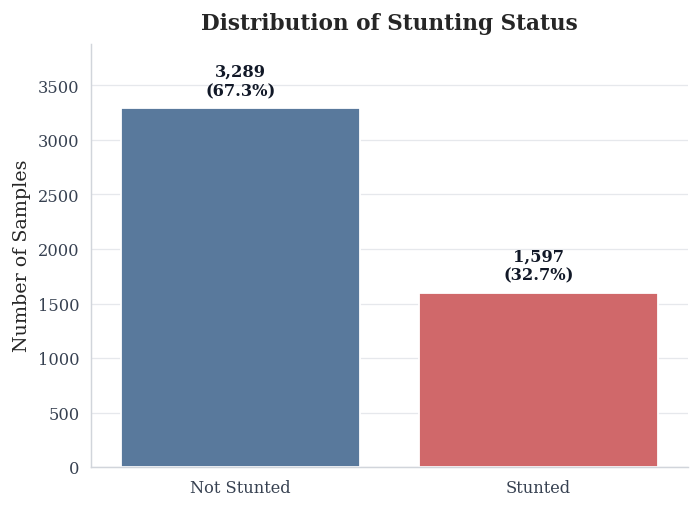

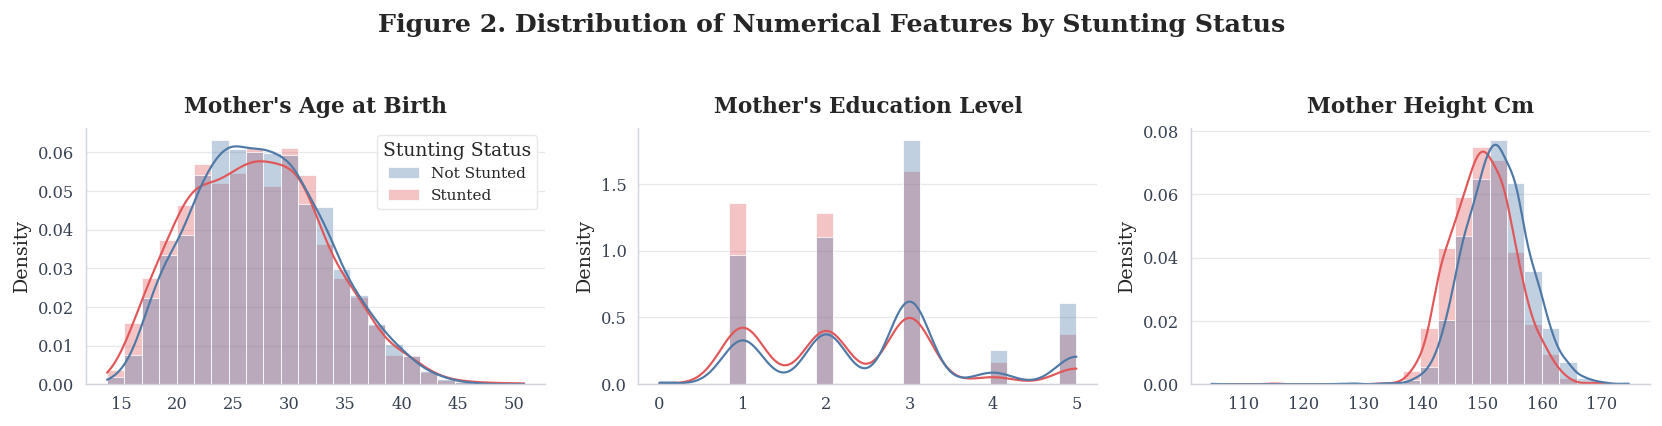

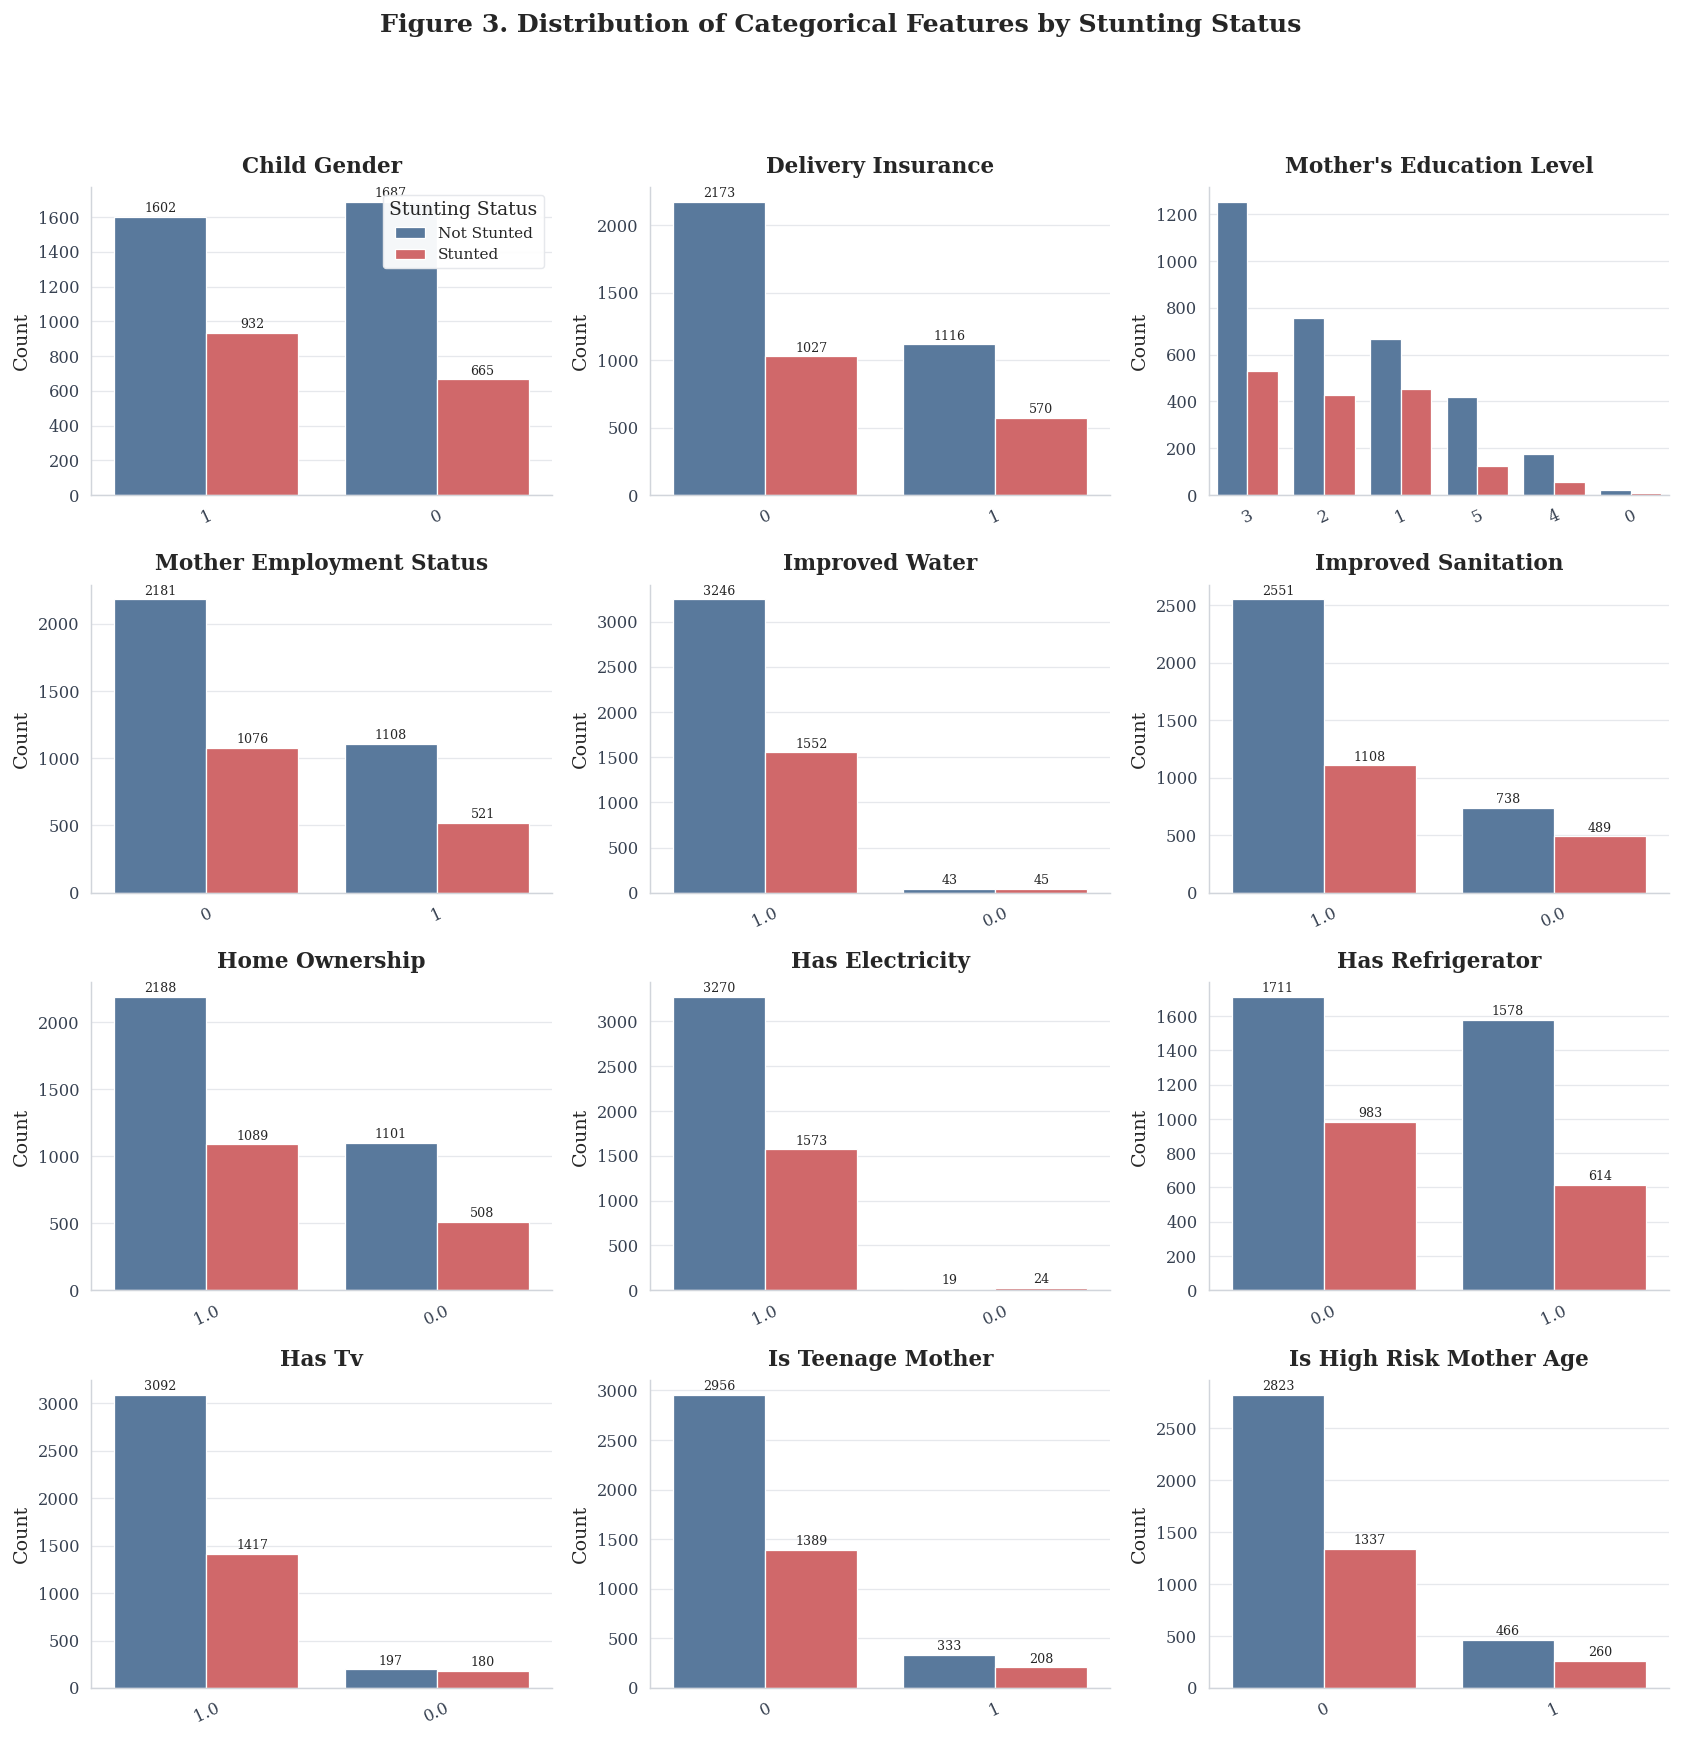

In [4]:
plot_df = make_target_plot_df(df)

# -----------------------------------------------------------------------------
# Figure 1. Target distribution with counts and percentages
# -----------------------------------------------------------------------------
target_counts = (
    plot_df["Stunting Status"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    palette=CLASS_PALETTE,
    ax=ax,
    edgecolor="white",
    linewidth=1.0,
)

for idx, value in enumerate(target_counts.values):
    pct = value / len(plot_df) * 100
    ax.text(
        idx,
        value + max(target_counts.values) * 0.025,
        f"{value:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#111827",
    )

ax.set_title("Distribution of Stunting Status")
ax.set_xlabel("")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, max(target_counts.values) * 1.18)
style_axis(ax)
save_figure(fig, "eda_target_distribution_clean.png", top=0.96)
plt.show()

# -----------------------------------------------------------------------------
# Figure 2-style. Numerical feature distributions by stunting status
# Inspired by the paper layout: compact multi-panel density/histogram grid.
# -----------------------------------------------------------------------------
preferred_numeric = [
    "birth_weight_kg", "birth_weight", "age", "child_age", "weight_kg",
    "weight", "height_cm", "height", "father_education",
    "mother_education", "mother_age_at_birth", "household_food",
    "protein_intake", "pce"
]

numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != TARGET_COL and df[col].nunique(dropna=True) > 5
]

numeric_cols = (
    [col for col in preferred_numeric if col in numeric_cols] +
    [col for col in numeric_cols if col not in preferred_numeric]
)

max_numeric_features = min(len(numeric_cols), 12)
numeric_cols = numeric_cols[:max_numeric_features]

if len(numeric_cols) == 0:
    print("No continuous numerical features found for distribution plots.")
else:
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.3 * n_cols, 3.25 * n_rows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        ax = axes_flat[idx]
        sns.histplot(
            data=plot_df,
            x=col,
            hue="Stunting Status",
            hue_order=CLASS_ORDER,
            palette=CLASS_PALETTE,
            bins=24,
            kde=True,
            stat="density",
            common_norm=False,
            alpha=0.35,
            linewidth=0.4,
            edgecolor="white",
            ax=ax,
            legend=(idx == 0),
        )
        ax.set_title(pretty_name(col, width=28))
        ax.set_xlabel("")
        ax.set_ylabel("Density")
        style_axis(ax)

        legend = ax.get_legend()
        if legend is not None:
            legend.set_title("Stunting Status")
            legend.get_frame().set_facecolor("white")
            legend.get_frame().set_edgecolor("#E5E7EB")
            legend.get_frame().set_alpha(0.95)

    for empty_ax in axes_flat[len(numeric_cols):]:
        empty_ax.axis("off")

    fig.suptitle(
        "Figure 2. Distribution of Numerical Features by Stunting Status",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    save_figure(fig, "eda_numerical_distributions_paper_style.png", top=0.95)
    plt.show()

# -----------------------------------------------------------------------------
# Figure 3-style. Categorical and binary feature distributions
# -----------------------------------------------------------------------------
preferred_categorical = [
    "premature_status", "breastfeeding", "exclusive_breastfeeding",
    "father_occupation", "mother_occupation", "child_gender", "water",
    "toilet", "smoking", "teenage_mother", "high_risk_maternal_age",
    "has_delivery_insurance", "mother_education_level"
]

categorical_cols = [
    col for col in df.columns
    if col != TARGET_COL and (
        df[col].dtype == "object" or
        str(df[col].dtype).startswith("category") or
        df[col].nunique(dropna=True) <= 6
    )
]

categorical_cols = (
    [col for col in preferred_categorical if col in categorical_cols] +
    [col for col in categorical_cols if col not in preferred_categorical]
)

max_categorical_features = min(len(categorical_cols), 12)
categorical_cols = categorical_cols[:max_categorical_features]

if len(categorical_cols) == 0:
    print("No categorical or binary features found for count plots.")
else:
    n_cols = 3
    n_rows = math.ceil(len(categorical_cols) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.35 * n_cols, 3.35 * n_rows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for idx, col in enumerate(categorical_cols):
        ax = axes_flat[idx]
        tmp = plot_df[[col, "Stunting Status"]].dropna().copy()
        tmp[col] = tmp[col].astype(str)
        order = tmp[col].value_counts().index.tolist()[:8]
        tmp[col] = np.where(tmp[col].isin(order), tmp[col], "Other")
        order = [str(item) for item in order if str(item) in tmp[col].unique()]
        if "Other" in tmp[col].unique():
            order.append("Other")

        sns.countplot(
            data=tmp,
            x=col,
            hue="Stunting Status",
            hue_order=CLASS_ORDER,
            order=order,
            palette=CLASS_PALETTE,
            ax=ax,
            edgecolor="white",
            linewidth=0.7,
        )

        ax.set_title(pretty_name(col, width=28))
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=25)
        style_axis(ax)

        if len(order) <= 4:
            add_bar_labels(ax, fmt="{:.0f}", fontsize=7, padding=1)

        legend = ax.get_legend()
        if legend is not None:
            if idx == 0:
                legend.set_title("Stunting Status")
                legend.get_frame().set_facecolor("white")
                legend.get_frame().set_edgecolor("#E5E7EB")
                legend.get_frame().set_alpha(0.95)
            else:
                legend.remove()

    for empty_ax in axes_flat[len(categorical_cols):]:
        empty_ax.axis("off")

    fig.suptitle(
        "Figure 3. Distribution of Categorical Features by Stunting Status",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    save_figure(fig, "eda_categorical_distributions_paper_style.png", top=0.95)
    plt.show()


## 6. Feature Correlation Analysis


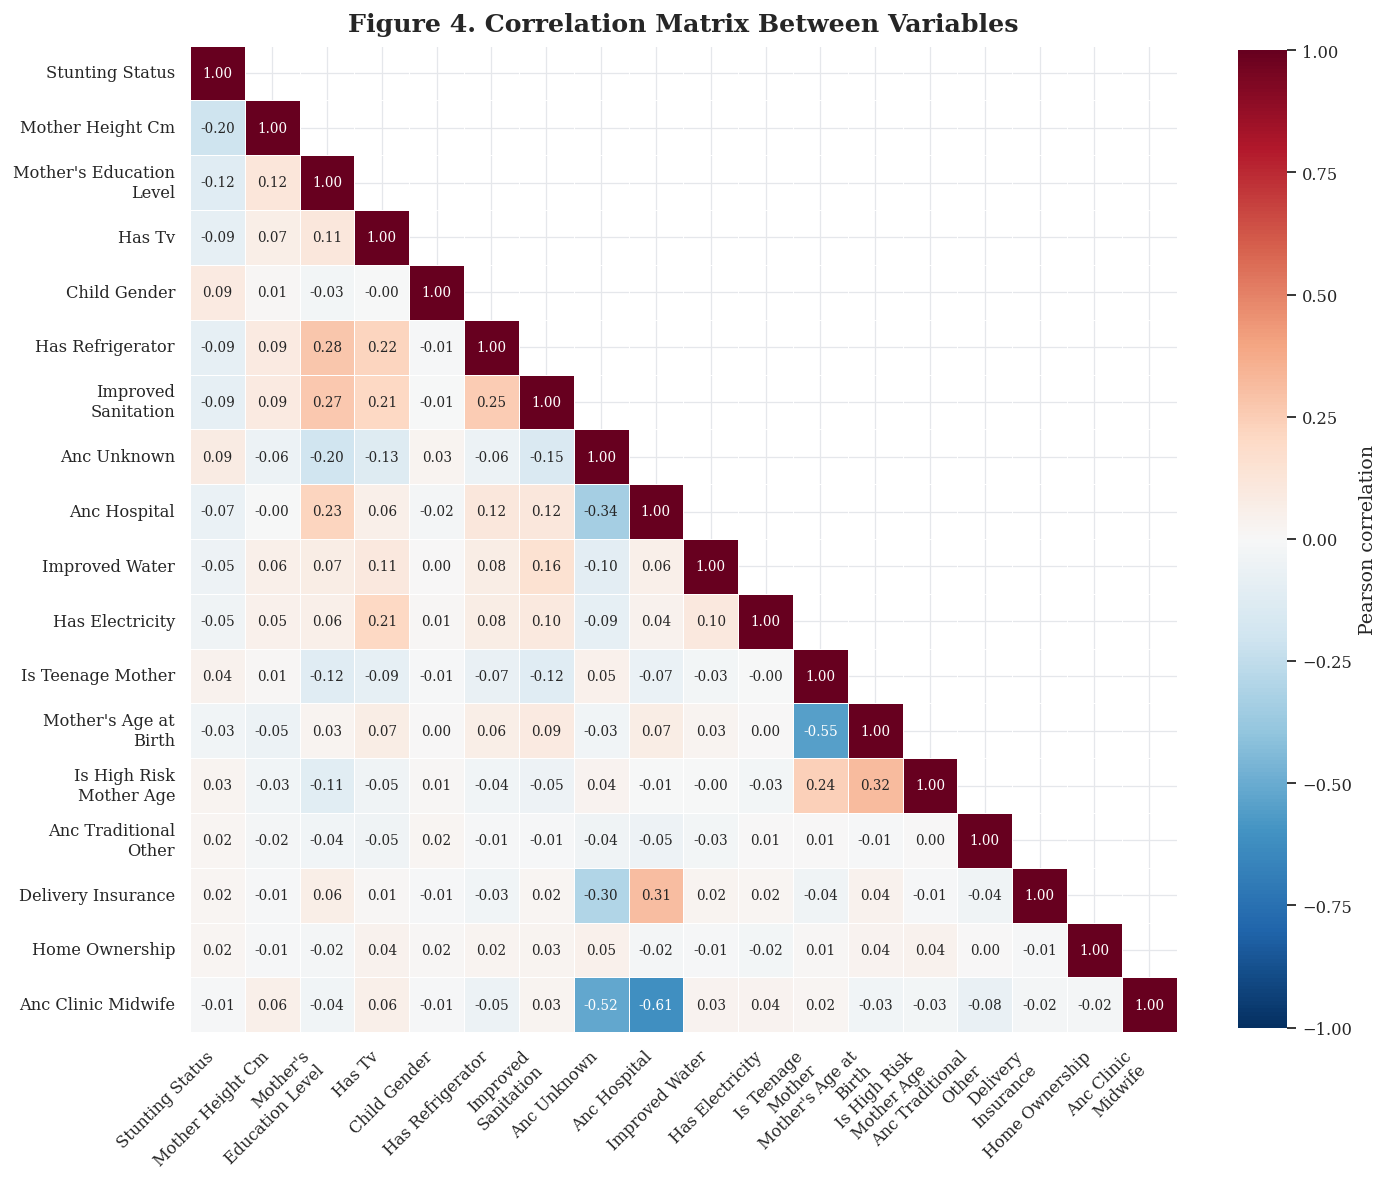

In [5]:
corr = df.corr(numeric_only=True)

# Keep annotation readable. If the dataset has many numeric columns, show the
# most target-relevant variables plus the target column.
if TARGET_COL in corr.columns and corr.shape[0] > 18:
    top_corr_features = (
        corr[TARGET_COL]
        .abs()
        .sort_values(ascending=False)
        .head(18)
        .index
        .tolist()
    )
    corr_plot = corr.loc[top_corr_features, top_corr_features]
else:
    corr_plot = corr.copy()

mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)
annot = corr_plot.shape[0] <= 18

fig, ax = plt.subplots(figsize=(max(8, 0.62 * corr_plot.shape[1]), max(6.8, 0.58 * corr_plot.shape[0])))
sns.heatmap(
    corr_plot,
    mask=mask,
    annot=annot,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.45,
    linecolor="white",
    cbar_kws={"shrink": 0.78, "label": "Pearson correlation"},
    annot_kws={"fontsize": 7.5},
    ax=ax,
)

ax.set_title("Figure 4. Correlation Matrix Between Variables", fontsize=14, fontweight="bold")
ax.set_xticklabels([pretty_name(label.get_text(), width=16) for label in ax.get_xticklabels()], rotation=45, ha="right")
ax.set_yticklabels([pretty_name(label.get_text(), width=18) for label in ax.get_yticklabels()], rotation=0)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "correlation_matrix_paper_style.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## 7. Train-Test Split

The dataset is split using an 80:20 stratified split to preserve the target class distribution.


In [6]:
X = df.drop(columns=["is_stunted"])
y = df["is_stunted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

print("\nTraining target distribution:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
display((y_test.value_counts(normalize=True) * 100).round(2))


Training set: 3908 samples
Testing set: 978 samples

Training target distribution:


is_stunted
0    67.32
1    32.68
Name: proportion, dtype: float64


Testing target distribution:


is_stunted
0    67.28
1    32.72
Name: proportion, dtype: float64

## 8. Cross-Validation

Five-fold stratified cross-validation is used to estimate model generalization more robustly.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )

scoring = {
    "accuracy": "accuracy",
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Model": name,
        "Accuracy": f"{res['test_accuracy'].mean():.3f} +/- {res['test_accuracy'].std():.3f}",
        "Recall": f"{res['test_recall'].mean():.3f} +/- {res['test_recall'].std():.3f}",
        "F1": f"{res['test_f1'].mean():.3f} +/- {res['test_f1'].std():.3f}",
        "ROC-AUC": f"{res['test_roc_auc'].mean():.3f} +/- {res['test_roc_auc'].std():.3f}",
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df)


,Model,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.613 +/- 0.015,0.599 +/- 0.025,0.503 +/- 0.015,0.659 +/- 0.015
1,Random Forest,0.660 +/- 0.007,0.248 +/- 0.021,0.323 +/- 0.021,0.616 +/- 0.013
2,XGBoost,0.617 +/- 0.011,0.418 +/- 0.014,0.416 +/- 0.011,nan +/- nan


## 9. Model Training and Evaluation


In [8]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

metrics_df = pd.DataFrame({
    name: [
        r["accuracy"],
        r["precision"],
        r["recall"],
        r["f1"],
        r["auc"]
    ]
    for name, r in results.items()
}, index=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]).T

display(metrics_df.round(4))

for name, r in results.items():
    print(f"\nClassification Report: {name}")
    print(classification_report(y_test, r["y_pred"]))


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.6104,0.4350,0.6375,0.5171,0.6561
Random Forest,0.6575,0.4571,0.2500,0.3232,0.6178
XGBoost,0.6196,0.4207,0.4312,0.4259,0.6067



Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.60      0.67       658
           1       0.43      0.64      0.52       320

    accuracy                           0.61       978
   macro avg       0.60      0.62      0.60       978
weighted avg       0.66      0.61      0.62       978


Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       658
           1       0.46      0.25      0.32       320

    accuracy                           0.66       978
   macro avg       0.58      0.55      0.55       978
weighted avg       0.62      0.66      0.62       978


Classification Report: XGBoost
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       658
           1       0.42      0.43      0.43       320

    accuracy                           0.62       978
   macro avg  

## 10. Model Comparison Visualization


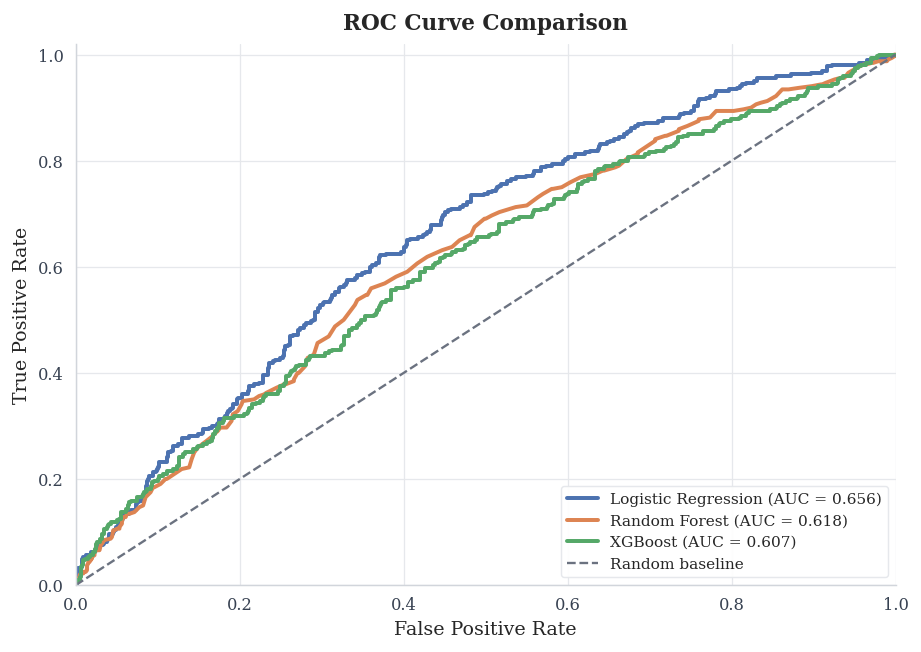

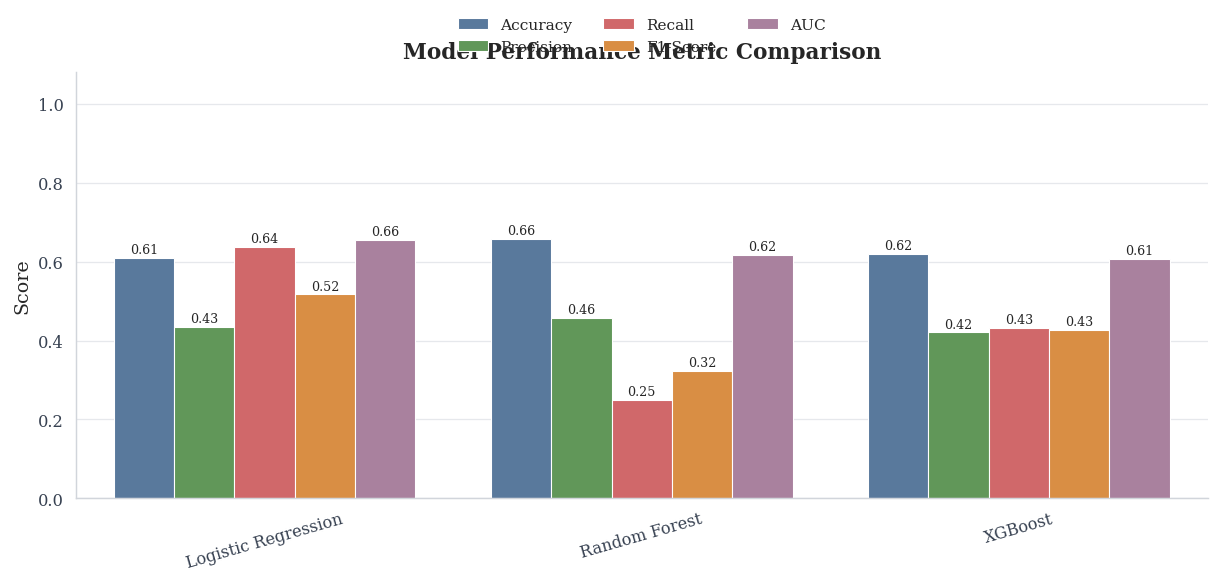

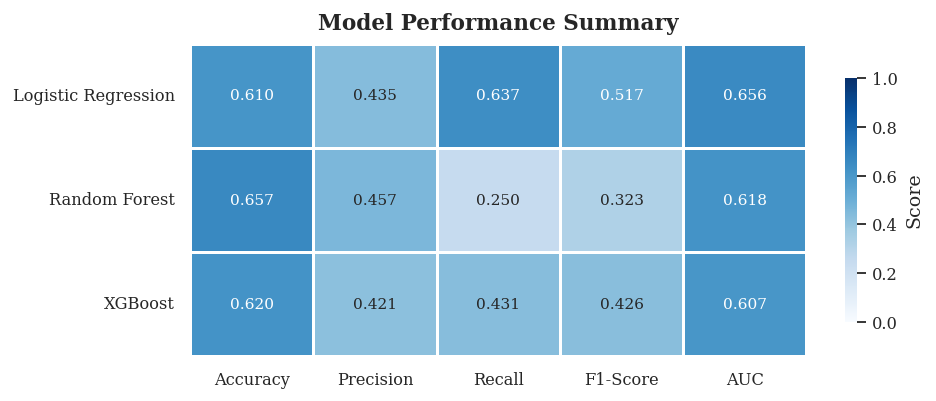

In [9]:
# -----------------------------------------------------------------------------
# ROC curve comparison
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.4))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.3, color=NEUTRAL_GRAY, label="Random baseline")
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
style_axis(ax, grid_axis="both")
ax.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="#E5E7EB")
save_figure(fig, "roc_curve_comparison_clean.png", top=0.95)
plt.show()

# -----------------------------------------------------------------------------
# Detailed metric comparison as grouped bars
# -----------------------------------------------------------------------------
metrics_for_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
metric_long = (
    metrics_df[metrics_for_plot]
    .rename_axis("Model")
    .reset_index()
    .melt(id_vars="Model", var_name="Metric", value_name="Score")
)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
sns.barplot(
    data=metric_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette=METRIC_PALETTE,
    ax=ax,
    edgecolor="white",
    linewidth=0.6,
)

ax.set_title("Model Performance Metric Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.tick_params(axis="x", rotation=16)
style_axis(ax)
add_bar_labels(ax, fmt="{:.2f}", fontsize=7, padding=1)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.16), frameon=False)
save_figure(fig, "model_metric_comparison_clean.png", top=0.88)
plt.show()

# -----------------------------------------------------------------------------
# Metric heatmap for manuscript-style compact comparison table
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, max(3.2, 0.58 * len(metrics_df))))
sns.heatmap(
    metrics_df[metrics_for_plot],
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.78, "label": "Score"},
    annot_kws={"fontsize": 8.5},
    ax=ax,
)
ax.set_title("Model Performance Summary")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_metric_heatmap_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## 11. Confusion Matrix


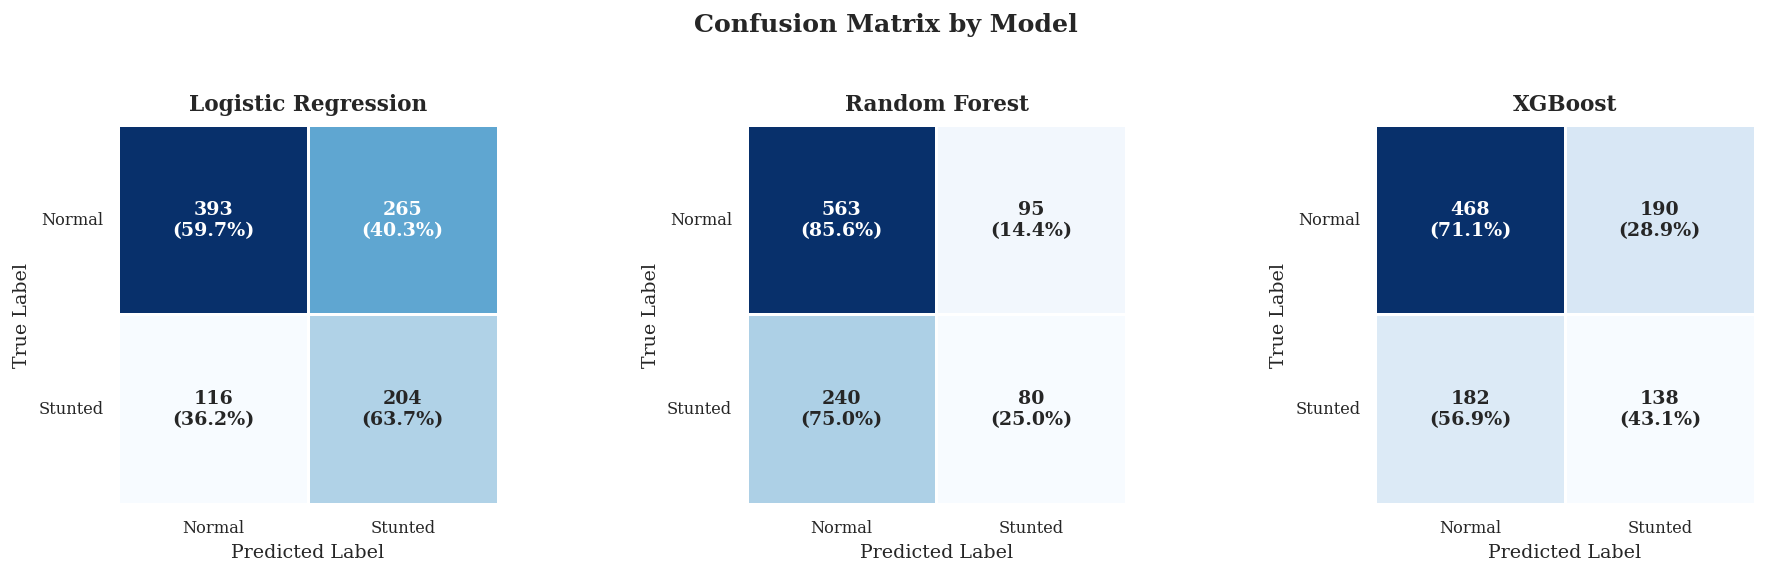

In [10]:
fig_cm, axes_cm = plt.subplots(1, len(results), figsize=(4.9 * len(results), 4.25), squeeze=False)
axes_cm = axes_cm.flatten()

for ax, (name, r) in zip(axes_cm, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    row_totals = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals != 0) * 100
    labels = np.array([
        [f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.8,
        linecolor="white",
        annot_kws={"size": 10.5, "weight": "bold"},
        xticklabels=["Normal", "Stunted"],
        yticklabels=["Normal", "Stunted"],
        square=True,
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis="both", labelrotation=0)

for empty_ax in axes_cm[len(results):]:
    empty_ax.axis("off")

fig_cm.suptitle("Confusion Matrix by Model", fontsize=14, fontweight="bold", y=1.03)
fig_cm.tight_layout()
fig_cm.savefig(FIGURE_DIR / "confusion_matrices_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## 12. Best Model Selection

The best model is selected by prioritizing F1-Score, Recall, and AUC for the stunted class.


In [11]:
best_name = max(results, key=lambda x: (results[x]["f1"], results[x]["recall"], results[x]["auc"]))
best_model = results[best_name]["model"]

print(f"Best model: {best_name}")
print(f"F1-Score: {results[best_name]['f1']:.4f}")
print(f"Recall:   {results[best_name]['recall']:.4f}")
print(f"AUC:      {results[best_name]['auc']:.4f}")


Best model: Logistic Regression
F1-Score: 0.5171
Recall:   0.6375
AUC:      0.6561


## 13. Threshold Tuning

Threshold tuning is applied to support screening by improving sensitivity to stunting risk.


,Threshold,Precision,Recall,F1-Score
0,0.20,0.3289,0.9938,0.4942
1,0.25,0.3337,0.9812,0.4980
2,0.30,0.3472,0.9625,0.5104
3,0.35,0.3651,0.9219,0.5230
4,0.40,0.3837,0.8406,0.5269
5,0.45,0.4126,0.7594,0.5347
6,0.50,0.4350,0.6375,0.5171
7,0.55,0.4611,0.4812,0.4709
8,0.60,0.4566,0.3125,0.3711
9,0.65,0.5156,0.2062,0.2946


Optimal threshold: 0.45
Precision: 0.4126
Recall: 0.7594
F1-Score: 0.5347


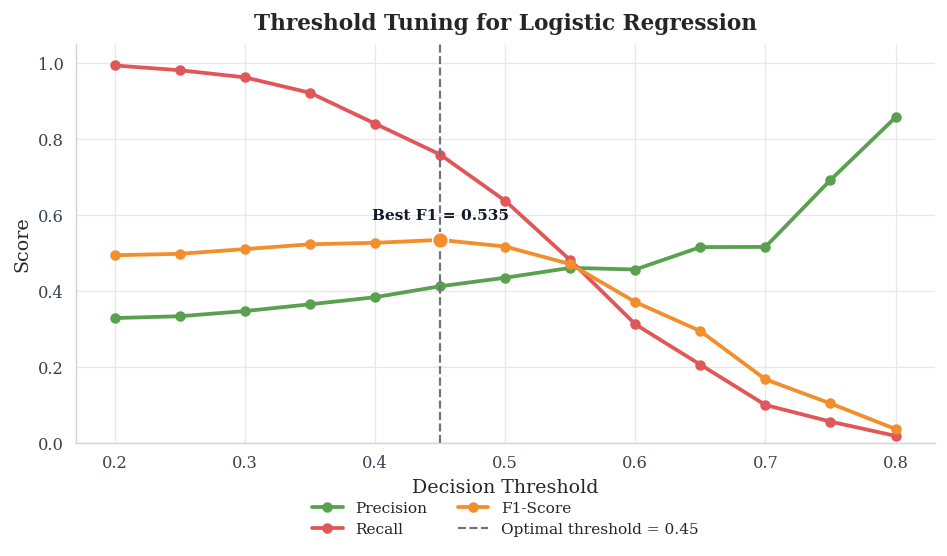

In [12]:
thresholds = np.round(np.arange(0.20, 0.81, 0.05), 2)
tuning_rows = []
y_best_prob = results[best_name]["y_prob"]

for threshold in thresholds:
    pred_threshold = (y_best_prob >= threshold).astype(int)
    tuning_rows.append({
        "Threshold": float(threshold),
        "Precision": precision_score(y_test, pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test, pred_threshold, zero_division=0)
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df.round(4))

best_tune = tuning_df.loc[tuning_df["F1-Score"].idxmax()]
optimal_threshold = float(best_tune["Threshold"])

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Precision: {best_tune['Precision']:.4f}")
print(f"Recall: {best_tune['Recall']:.4f}")
print(f"F1-Score: {best_tune['F1-Score']:.4f}")

fig, ax = plt.subplots(figsize=(7.4, 4.8))
for metric in ["Precision", "Recall", "F1-Score"]:
    ax.plot(
        tuning_df["Threshold"],
        tuning_df[metric],
        marker="o",
        linewidth=2.1,
        markersize=4.8,
        label=metric,
        color=METRIC_PALETTE.get(metric),
    )

ax.axvline(
    optimal_threshold,
    color=NEUTRAL_GRAY,
    linestyle="--",
    linewidth=1.2,
    label=f"Optimal threshold = {optimal_threshold:.2f}",
)
ax.scatter(
    [optimal_threshold],
    [best_tune["F1-Score"]],
    s=75,
    color=METRIC_PALETTE["F1-Score"],
    edgecolor="white",
    linewidth=0.8,
    zorder=4,
)
ax.text(
    optimal_threshold,
    min(1.02, best_tune["F1-Score"] + 0.045),
    f"Best F1 = {best_tune['F1-Score']:.3f}",
    ha="center",
    va="bottom",
    fontsize=8.5,
    fontweight="bold",
    color="#111827",
)

ax.set_title(f"Threshold Tuning for {best_name}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
style_axis(ax, grid_axis="both")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.27), ncol=2, frameon=False)
save_figure(fig, "threshold_tuning_clean.png", top=0.95)
plt.show()


## 14. Save Model Artifacts


In [13]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC-AUC": r["auc"]
    }
    for name, r in results.items()
])

joblib.dump(best_model, MODEL_DIR / "stunting_model.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "feature_columns.pkl")
joblib.dump(optimal_threshold, MODEL_DIR / "stunting_threshold.pkl")

comparison.to_csv(PROJECT_ROOT / "Data/processed/07_model_comparison.csv", index=False)
tuning_df.to_csv(PROJECT_ROOT / "Data/processed/07_threshold_tuning.csv", index=False)

print("All Step 7 artifacts saved.")


All Step 7 artifacts saved.


---

# Step 8: Explainable AI

SHAP is used as the primary XAI method because it supports both global and local interpretation. LIME is used as a local comparison method.


## 15. SHAP Global Interpretability


In [14]:
if not SHAP_AVAILABLE:
    raise ImportError("SHAP is not installed. Run: pip install shap")

if isinstance(best_model, LogisticRegression):
    explainer = shap.LinearExplainer(best_model, X_train)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values_raw = explainer.shap_values(X_test)

if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw

print("SHAP values shape:", np.array(shap_vals).shape)


SHAP values shape: (978, 18)


## 16. SHAP Summary Plot


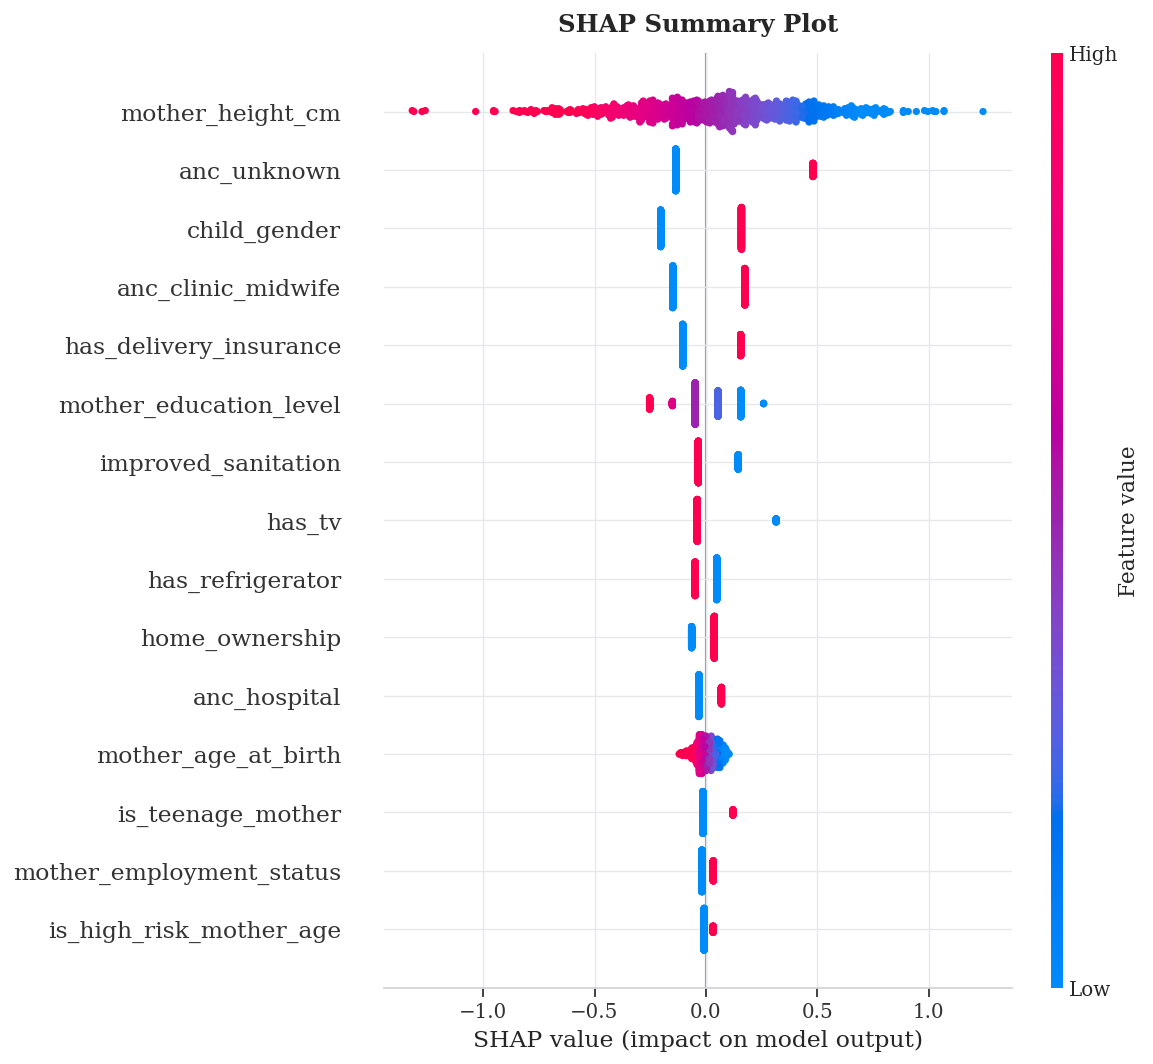

In [15]:
shap.summary_plot(shap_vals, X_test, show=False, max_display=min(15, X_test.shape[1]))
fig = plt.gcf()
fig.set_size_inches(9.2, max(5.8, 0.42 * min(15, X_test.shape[1]) + 2.0))
plt.title("SHAP Summary Plot", fontsize=13.5, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_summary_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## 17. SHAP Feature Importance


,Feature,Mean |SHAP|
3,mother_height_cm,0.310520
17,anc_unknown,0.218791
0,child_gender,0.180022
14,anc_clinic_midwife,0.160970
13,has_delivery_insurance,0.121674
1,mother_education_level,0.102512
5,improved_sanitation,0.062882
9,has_tv,0.058442
8,has_refrigerator,0.048693
6,home_ownership,0.046633


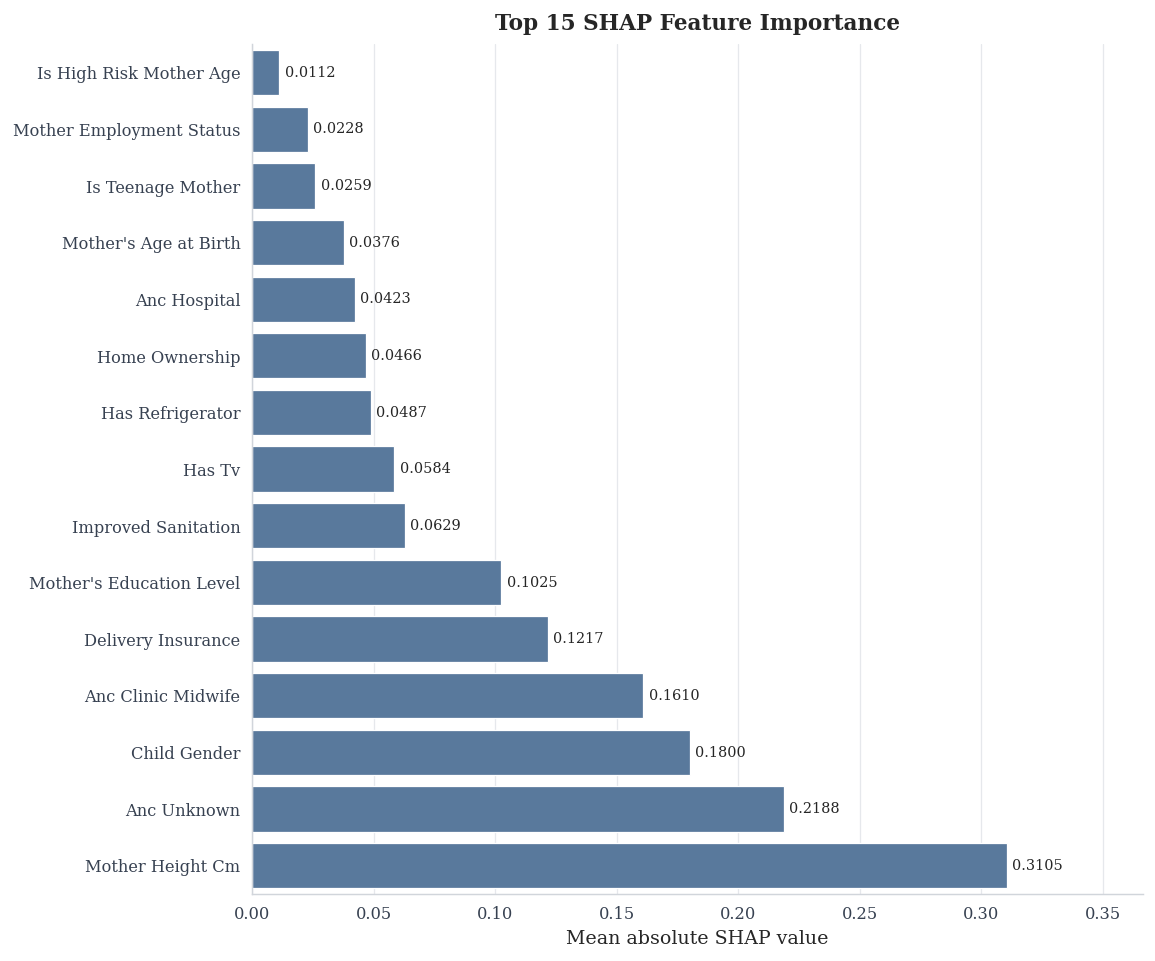

In [16]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": mean_abs_shap
})

shap_importance_sorted = shap_importance.sort_values("Mean |SHAP|", ascending=False)
display(shap_importance_sorted)

plot_top_n = min(15, len(shap_importance_sorted))
shap_plot = shap_importance_sorted.head(plot_top_n).sort_values("Mean |SHAP|", ascending=True).copy()
shap_plot["Feature Label"] = shap_plot["Feature"].apply(lambda x: pretty_name(x, width=34))

fig, ax = plt.subplots(figsize=(9.0, max(4.8, 0.42 * plot_top_n + 1.6)))
sns.barplot(
    data=shap_plot,
    x="Mean |SHAP|",
    y="Feature Label",
    color=PRIMARY_BLUE,
    edgecolor="white",
    linewidth=0.7,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=3)

ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")
ax.set_title(f"Top {plot_top_n} SHAP Feature Importance")
style_axis(ax, grid_axis="x")
max_shap_value = shap_plot["Mean |SHAP|"].max()
ax.set_xlim(0, max_shap_value * 1.18 if max_shap_value > 0 else 1)
save_figure(fig, "shap_feature_importance_clean.png", top=0.95)
plt.show()

shap_importance_sorted.to_csv(
    PROJECT_ROOT / "Data/processed/08_shap_feature_importance.csv",
    index=False
)


## 18. SHAP Waterfall Plot

This plot explains one stunted sample by showing how each feature pushes the prediction toward or away from stunting risk.


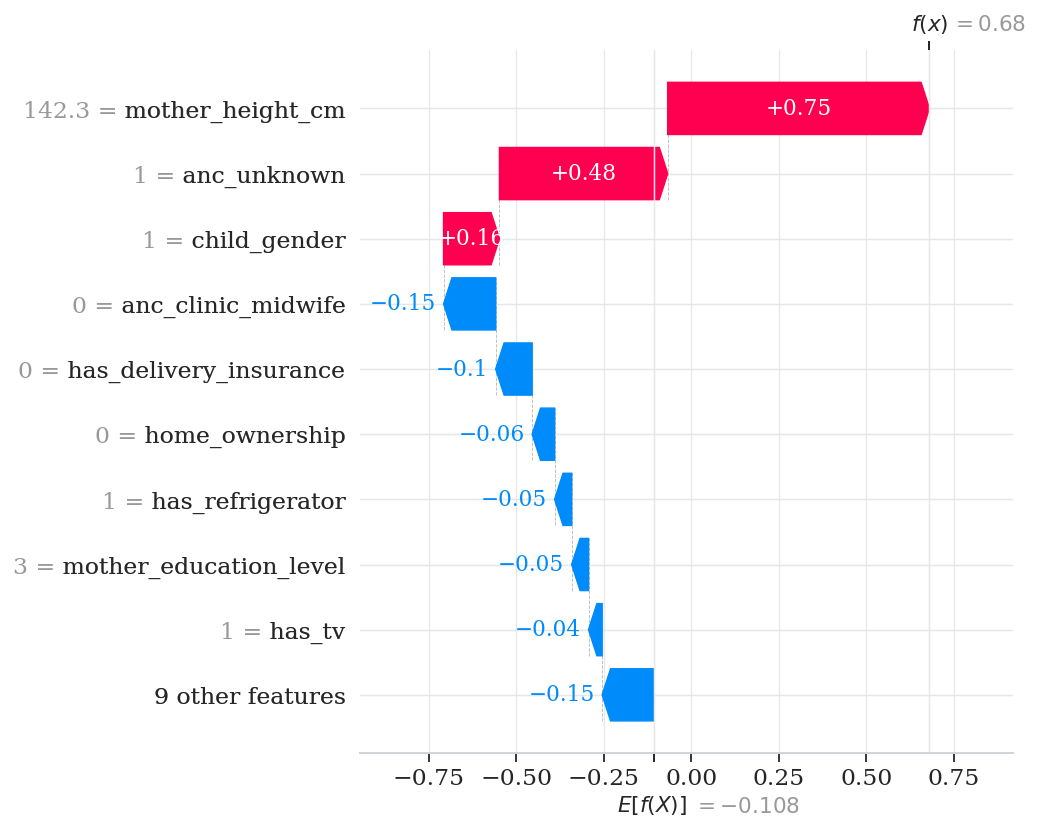

In [17]:
stunted_indices = np.where(y_test.values == 1)[0]

if len(stunted_indices) == 0:
    sample_idx = 0
else:
    sample_idx = stunted_indices[0]

sample_x = X_test.iloc[sample_idx]

if isinstance(best_model, LogisticRegression):
    base_value = explainer.expected_value
else:
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        base_value = expected_value[1]
    else:
        base_value = expected_value

explanation = shap.Explanation(
    values=shap_vals[sample_idx],
    base_values=base_value,
    data=sample_x.values,
    feature_names=list(X.columns)
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_waterfall_sample.png", bbox_inches="tight", dpi=300)
plt.show()


## 19. LIME Local Explanation

LIME is used as a local comparison method for the same sample explained by SHAP.


In [18]:
if not LIME_AVAILABLE:
    raise ImportError("LIME is not installed. Run: pip install lime")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Normal", "Stunted"],
    mode="classification",
    random_state=RANDOM_STATE
)

exp = lime_explainer.explain_instance(
    data_row=sample_x.values,
    predict_fn=best_model.predict_proba,
    num_features=len(X.columns)
)

lime_df = pd.DataFrame(exp.as_list(), columns=["Feature Rule", "Weight"])
lime_df["Direction"] = np.where(lime_df["Weight"] > 0, "Increases stunting risk", "Decreases stunting risk")
lime_df["Abs Weight"] = lime_df["Weight"].abs()
lime_df = lime_df.sort_values("Abs Weight", ascending=True)

display(lime_df.sort_values("Abs Weight", ascending=False).head(10))


,Feature Rule,Weight,Direction,Abs Weight
0,mother_height_cm <= 148.00,0.170904,Increases stunting risk,0.170904
1,anc_unknown > 0.00,0.142068,Increases stunting risk,0.142068
2,anc_traditional_other <= 0.00,-0.103594,Decreases stunting risk,0.103594
3,0.00 < child_gender <= 1.00,0.085520,Increases stunting risk,0.085520
4,anc_clinic_midwife <= 0.00,-0.077816,Decreases stunting risk,0.077816
5,has_delivery_insurance <= 0.00,-0.060221,Decreases stunting risk,0.060221
6,anc_hospital <= 0.00,-0.026044,Decreases stunting risk,0.026044
7,home_ownership <= 0.00,-0.025213,Decreases stunting risk,0.025213
8,is_teenage_mother <= 0.00,-0.024057,Decreases stunting risk,0.024057
9,0.00 < has_refrigerator <= 1.00,-0.023321,Decreases stunting risk,0.023321


## 20. LIME Visualization


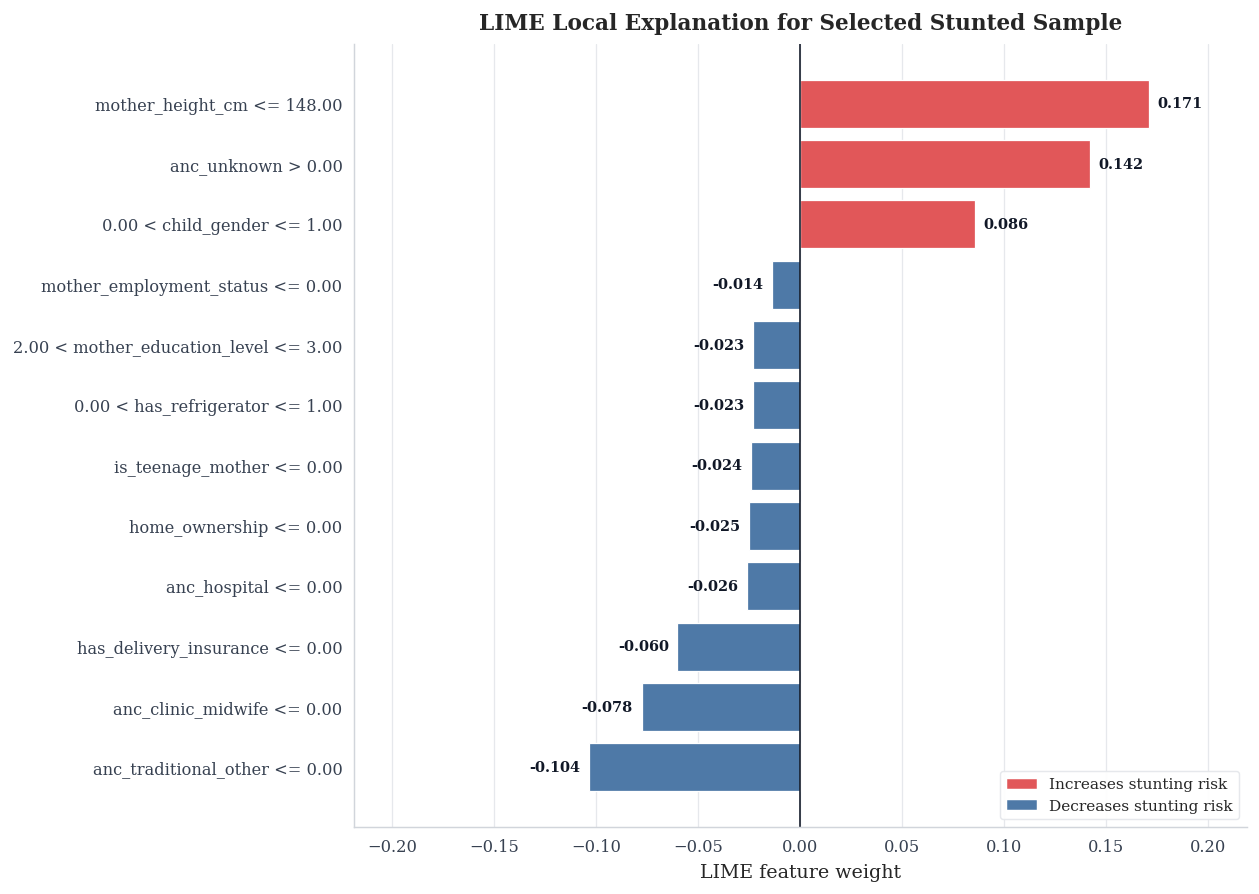

In [19]:
lime_top_n = min(12, len(lime_df))
lime_plot = lime_df.sort_values("Abs Weight", ascending=False).head(lime_top_n).copy()
lime_plot = lime_plot.sort_values("Weight", ascending=True)
lime_plot["Feature Rule Wrapped"] = lime_plot["Feature Rule"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=48, break_long_words=False))
)
colors = lime_plot["Weight"].apply(lambda x: RISK_RED if x > 0 else PRIMARY_BLUE)

fig, ax = plt.subplots(figsize=(9.8, max(5.2, 0.48 * lime_top_n + 1.6)))
ax.barh(
    lime_plot["Feature Rule Wrapped"],
    lime_plot["Weight"],
    color=colors,
    edgecolor="white",
    linewidth=0.7,
)
ax.axvline(0, color="#111827", linewidth=0.9)

for y_pos, value in enumerate(lime_plot["Weight"]):
    ha = "left" if value >= 0 else "right"
    offset = lime_plot["Weight"].abs().max() * 0.025
    ax.text(
        value + (offset if value >= 0 else -offset),
        y_pos,
        f"{value:.3f}",
        va="center",
        ha=ha,
        fontsize=8,
        color="#111827",
        fontweight="bold",
    )

ax.set_xlabel("LIME feature weight")
ax.set_ylabel("")
ax.set_title("LIME Local Explanation for Selected Stunted Sample")
legend_elements = [
    Patch(facecolor=RISK_RED, label="Increases stunting risk"),
    Patch(facecolor=PRIMARY_BLUE, label="Decreases stunting risk")
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True, framealpha=0.95, edgecolor="#E5E7EB")
style_axis(ax, grid_axis="x")
max_abs_weight = lime_plot["Weight"].abs().max()
max_abs_weight = max_abs_weight if max_abs_weight > 0 else 1
ax.set_xlim(-max_abs_weight * 1.28, max_abs_weight * 1.28)
save_figure(fig, "lime_explanation_sample_clean.png", top=0.95)
plt.show()


## 21. SHAP vs LIME Comparison

| Method | Interpretation | Strengths | Weaknesses | Role |
|---|---|---|---|---|
| **SHAP** | Global + Local | Mathematically grounded and consistent feature attribution | Higher computational cost | Primary XAI method |
| **LIME** | Local only | Intuitive and easy to explain for one prediction | Less stable due to local sampling | Local comparison |


## 22. XAI Validation Summary


In [20]:
print(f"Best model: {best_name}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print(f"LIME available: {LIME_AVAILABLE}")

print("\nSaved figures:")
for fig_path in sorted(FIGURE_DIR.glob("*.png")):
    print(fig_path)

print("\nSaved artifacts:")
for artifact_path in sorted(MODEL_DIR.glob("*.pkl")):
    print(artifact_path)


Best model: Logistic Regression
X_train shape: (3908, 18)
X_test shape: (978, 18)
Number of features: 18
SHAP available: True
LIME available: True

Saved figures:
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/confusion_matrices.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/confusion_matrices_clean.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/correlation_matrix.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/correlation_matrix_paper_style.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/eda_categorical_distributions_paper_style.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/eda_numerical_distributions_paper_style.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/eda_overview.png
/Users/arya/Documents/Tugas Akhir/prenava/stunting ml/models/figures/eda_target_distribution_clean.png
/Users/arya/Documents/Tugas Akhir/

## 23. Interpretation

SHAP is used as the main Explainable AI method because it provides both global and local feature attribution more consistently, while LIME is used as a local comparison method. The moderate model performance reflects the multifactorial nature of stunting, where maternal and socioeconomic variables explain only part of the risk. Therefore, the model is positioned as an early warning system for Prenava, not as a definitive diagnostic tool.
